In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Resume.csv")
df.sample(2)

,Category,Resume
238,Sales,IT Skills: MS Office. Photoshop. SQL Server.Ed...
318,Civil Engineer,PERSONAL SKILLS â¢ Passionate towards learnin...


In [ ]:
df["Category"].iloc[0]

'Data Science'

In [ ]:
df["Resume"].iloc[0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

In [ ]:
df.shape

(962, 2)

In [ ]:
df["Category"].nunique()

25

In [ ]:
df["Category"].value_counts()

,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


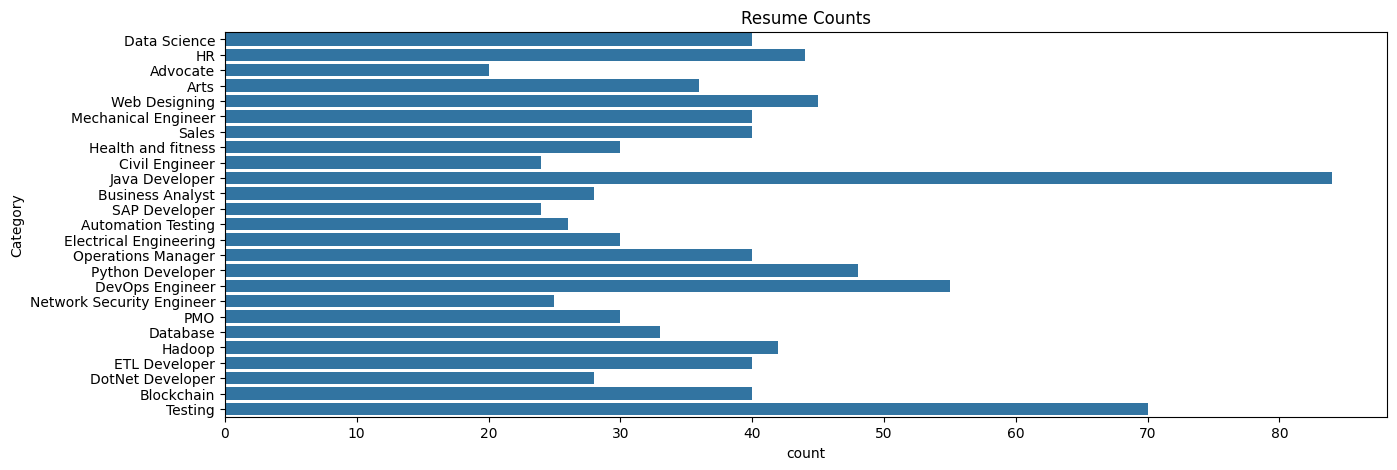

In [ ]:
plt.figure(figsize = (15,5))
sns.countplot(df["Category"])
plt.title("Resume Counts")
plt.show()

In [ ]:
# Oversampling to handle class imbalance
max_size = df["Category"].value_counts().max()
balanced_df = df.groupby("Category").apply(lambda x:x.sample(max_size,replace=True)).reset_index(drop=True)
df = balanced_df.sample(frac=1).reset_index(drop=True)

/tmp/ipykernel_3520/708454809.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("Category").apply(lambda x:x.sample(max_size,replace=True)).reset_index(drop=True)


In [ ]:
df

,Category,Resume
0,DotNet Developer,Participated in intra college cricket competit...
1,Testing,COMPUTER PROFICIENCY â¢ Basic: MS-Office (Pow...
2,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...
3,Operations Manager,KEY COMPETENCIES â¶Multi - Operations Managem...
4,ETL Developer,Technical Summary â¢ Knowledge of Informatica...
...,...,...
2095,Hadoop,Technical Skill Set: Programming Languages Apa...
2096,Sales,KEY SKILLS: â¢ Planning & Strategizing â¢ Pr...
2097,Database,"TECHNICAL SKILL: Operating System LINUX, Windo..."
2098,Web Designing,"Technical Skills Web Technologies: Angular JS,..."


## Cleaning Data :
1. URLs
2. Hashtags
3. Mentions
4. Special Characters
5. Punctutaion

In [ ]:
import re
def cleanResume(txt):
    cleanText = re.sub('http\S+\s', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3520/3739445999.py:3: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('http\S+\s', ' ', txt)
/tmp/ipykernel_3520/3739445999.py:5: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('#\S+\s', ' ', cleanText)
/tmp/ipykernel_3520/3739445999.py:6: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('@\S+', '  ', cleanText)
/tmp/ipykernel_3520/3739445999.py:7: SyntaxWarning: invalid escape sequence '\]'
  cleanText = re.sub('[%s]' % re.escape

In [ ]:
cleanResume("hii :), i am mohammad bilal!!")

'hii i am mohammad bilal '

In [ ]:
df["Resume"][0]

'Participated in intra college cricket competition and various other sports events. Group dance in college cultural programme Education Details \r\n Msc Computer Science Pune, Maharashtra Pune University\r\n Bsc Computer Science Pune, Maharashtra Pune University\r\n HSC Semi-English Pune, Maharashtra Maharashatra Board\r\n SSC Semi-English Pune, Maharashtra Maharashatra Board\r\nDOT NET Developer \r\n\r\nDot Net Developer\r\nSkill Details \r\nAsp.Net,C#, HTML, CSS, SQL- Exprience - 6 months\r\nJavascript- Exprience - Less than 1 year months\r\nsql server 2008/2012- Exprience - Less than 1 year monthsCompany Details \r\ncompany - \r\ndescription - '

In [ ]:
df["Resume"] = df["Resume"].apply(lambda x:cleanResume(x))
df["Resume"][0]

'Participated in intra college cricket competition and various other sports events Group dance in college cultural programme Education Details Msc Computer Science Pune Maharashtra Pune University Bsc Computer Science Pune Maharashtra Pune University HSC Semi English Pune Maharashtra Maharashatra Board SSC Semi English Pune Maharashtra Maharashatra Board DOT NET Developer Dot Net Developer Skill Details Asp Net C HTML CSS SQL Exprience 6 months Javascript Exprience Less than 1 year months sql server 2008 2012 Exprience Less than 1 year monthsCompany Details company description '

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
le.fit(df["Category"])
df["Category"] = le.transform(df["Category"])
df["Category"].unique()

array([ 9, 23, 18, 10,  4, 21, 17,  0, 14,  3,  8, 24,  1,  7,  6, 12,  2,
       19,  5, 13, 11, 20, 16, 22, 15])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words="english")
tfidf.fit(df["Resume"])
required_text = tfidf.transform(df["Resume"])

In [ ]:
from sklearn.model_selection import train_test_split

# total 100 rows
# traning 80 rows
# testing 20 rows

X_train,X_test,y_train,y_test = train_test_split(required_text,df["Category"],test_size=0.2)

In [ ]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
svc_model = OneVsRestClassifier(SVC())
svc_model.fit(X_train,y_train)
y_pred = svc_model.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.9952380952380953

In [ ]:
def pred(Resume_input):
  # Preprocessing
  cleaned_text = cleanResume(Resume_input)

  # Convert text into numeric values
  numeric_text = tfidf.transform([cleaned_text])

  # Convert matrix into array
  numeric_text = numeric_text.toarray()

  # Prediction
  # predicted_category = svc_model.predict(numeric_text)

  predicted_category_name = le.inverse_transform(svc_model.predict(numeric_text))
  return predicted_category_name[0]

In [ ]:
myresume = """I am a data scientist specializing in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Phone: 03442826192
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile data scientist with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

In [ ]:
pred(myresume)

'Data Science'

In [ ]:
myresume = """
Jane Smith is a certified personal trainer with over 5 years of experience in helping individuals achieve their fitness goals. Specializing in weight loss, strength training, and sports conditioning, Jane has developed personalized workout routines for clients of all ages and fitness levels. She has extensive knowledge in nutrition and exercise science, and uses this to create holistic health and fitness programs that are tailored to individual needs.

Jane holds a degree in Exercise Science and is a certified trainer through the National Academy of Sports Medicine (NASM). She has worked with athletes, seniors, and individuals with chronic health conditions, helping them improve their physical well-being and overall quality of life.

Her expertise includes:
- Weight Loss and Body Composition
- Strength Training and Resistance Exercises
- Cardio Conditioning
- Nutrition Coaching and Meal Planning
- Injury Prevention and Rehabilitation
- Functional Movement and Flexibility Training
- Group Fitness Classes

Certifications:
- Certified Personal Trainer, NASM
- CPR and First Aid Certified
- Yoga Instructor (200-Hour Certification)

Education:
BSc in Exercise Science, ABC University, 2014-2018

Work Experience:
- Personal Trainer at XYZ Fitness Gym (2018-Present)
- Fitness Coach at Wellness Center (2016-2018)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""

In [ ]:
pred(myresume)

'Health and fitness'